# 项目： 分析制造过程中出现的瓶颈

## 分析目标

此数据分析报告的目的是基于制造过程中收集到的数据，分析哪个工序是瓶颈、哪些因素影响生产效率、是否存在班次差异、是否存在操作员差异、如何改善，让我们可以对生产过程有个更清晰的认识和更明确的改善思路。

## 简介

原始数据`IE_Bottleneck_Study_1000.csv`由chatgpt生成，包含 `1000` 个样本，每个样本都有其中的一些属性

数据中包含  
产品编号       1000条生产记录  
日期	           连续生产日期  
班次	           白班/夜班  
操作员	            6名员工  
工序1_下料(s)  	 工序时间  
工序2_加工(s)  	 工序时间  
工序3_装配(s)	   工序时间  
工序4_检测(s)	   工序时间  
工序5_包装(s)	   工序时间  
停机时间(s)	       设备停机记录  
总工时(s)	       总生产时间

## 导入相关库与数据集

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# 引入t检验相关函数
from scipy.stats import ttest_ind

# 引入Z检验相关函数
from statsmodels.stats.weightstats import ztest

In [3]:
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']

In [4]:
original_data = pd.read_csv("IE_Bottleneck_Study_1000.csv")
original_data

,产品编号,日期,班次,操作员,工序1_下料(s),工序2_加工(s),工序3_装配(s),工序4_检测(s),工序5_包装(s),停机时间(s),总工时(s)
0,P00001,2026-01-01,白班,王五,13.87,19.04,25.40,14.61,10.79,0.00,83.71
1,P00002,2026-01-01,白班,李四,13.96,18.80,28.67,13.86,8.84,0.00,84.13
2,P00003,2026-01-01,白班,李四,11.53,17.11,21.98,16.36,9.95,0.00,76.93
3,P00004,2026-01-01,夜班,赵六,11.07,18.10,39.31,16.26,11.84,8.32,96.58
4,P00005,2026-01-01,白班,刘洋,10.83,16.64,30.57,12.87,10.77,0.00,81.68
...,...,...,...,...,...,...,...,...,...,...,...
995,P00996,2026-02-19,白班,刘洋,9.63,13.30,29.08,9.71,11.47,0.00,73.19
996,P00997,2026-02-19,夜班,刘洋,11.58,15.75,31.71,13.11,9.54,0.00,81.69
997,P00998,2026-02-19,白班,刘洋,9.90,14.41,31.76,13.88,9.17,0.00,79.12
998,P00999,2026-02-19,白班,陈强,11.00,20.37,28.10,14.76,10.44,0.00,84.67


## 评估和清洗数据

In [5]:
c_d = original_data.copy()

对原始数据做备份、对新的数据做评估和清洗

评估主要从两个方面进行：结构和内容，即`整齐度`和`干净度`。数据的结构性问题指不符合“每列是一个变量，每行是一个观察值，每个单元格是一个值”这三个标准，数据的内容性问题包括存在丢失数据、重复数据、无效数据等。

### 数据整齐度

In [6]:
c_d.head(10)

,产品编号,日期,班次,操作员,工序1_下料(s),工序2_加工(s),工序3_装配(s),工序4_检测(s),工序5_包装(s),停机时间(s),总工时(s)
0,P00001,2026-01-01,白班,王五,13.87,19.04,25.40,14.61,10.79,0.00,83.71
1,P00002,2026-01-01,白班,李四,13.96,18.80,28.67,13.86,8.84,0.00,84.13
2,P00003,2026-01-01,白班,李四,11.53,17.11,21.98,16.36,9.95,0.00,76.93
3,P00004,2026-01-01,夜班,赵六,11.07,18.10,39.31,16.26,11.84,8.32,96.58
4,P00005,2026-01-01,白班,刘洋,10.83,16.64,30.57,12.87,10.77,0.00,81.68
5,P00006,2026-01-01,夜班,陈强,12.66,19.15,39.31,16.49,8.43,12.76,96.04
6,P00007,2026-01-01,白班,刘洋,10.71,18.37,29.81,14.68,9.43,0.00,83.00
7,P00008,2026-01-01,白班,陈强,10.50,17.58,30.07,17.61,11.15,0.00,86.91
8,P00009,2026-01-01,白班,王五,13.07,17.11,28.40,15.40,9.03,0.00,83.01
9,P00010,2026-01-01,夜班,张三,11.21,19.39,31.94,14.20,10.60,0.00,87.34


从抽样的10行数据数据来看，数据符合“每列是一个变量，每行是一个观察值，每个单元格是一个值”，具体来看每行是关于生产产品的编号、工时等数据，每列是制造相关的的各个变量，因此不存在结构性问题。

### 数据干净度

In [7]:
original_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   产品编号       1000 non-null   object 
 1   日期         1000 non-null   object 
 2   班次         1000 non-null   object 
 3   操作员        1000 non-null   object 
 4   工序1_下料(s)  1000 non-null   float64
 5   工序2_加工(s)  985 non-null    float64
 6   工序3_装配(s)  1000 non-null   float64
 7   工序4_检测(s)  985 non-null    float64
 8   工序5_包装(s)  1000 non-null   float64
 9   停机时间(s)    1000 non-null   float64
 10  总工时(s)     1000 non-null   float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


从输出结果来看，数据共有1000条观察值，而仅有`工序2_加工(s)`、`工序4_检测(s)`变量存在缺失值。

此外，`日期`的数据类型应为日期，`班次`、`操作员`的数据类型应为category、以便后续分类与分析。

#### 处理数据类型

In [8]:
c_d["日期"] = pd.to_datetime(c_d["日期"], errors='coerce')
c_d["日期"]

0     2026-01-01
1     2026-01-01
2     2026-01-01
3     2026-01-01
4     2026-01-01
         ...    
995   2026-02-19
996   2026-02-19
997   2026-02-19
998   2026-02-19
999   2026-02-19
Name: 日期, Length: 1000, dtype: datetime64[ns]

In [9]:
c_d["班次"] = c_d["班次"].astype("category")
c_d["班次"]

0      白班
1      白班
2      白班
3      夜班
4      白班
       ..
995    白班
996    夜班
997    白班
998    白班
999    夜班
Name: 班次, Length: 1000, dtype: category
Categories (2, object): ['夜班', '白班']

In [10]:
c_d["操作员"] = c_d["操作员"].astype("category")
c_d["操作员"]

0      王五
1      李四
2      李四
3      赵六
4      刘洋
       ..
995    刘洋
996    刘洋
997    刘洋
998    陈强
999    王五
Name: 操作员, Length: 1000, dtype: category
Categories (6, object): ['刘洋', '张三', '李四', '王五', '赵六', '陈强']

成功将数据类型转换为合适格式

#### 处理缺失数据

In [11]:
c_d[c_d["工序2_加工(s)"].isnull()]

,产品编号,日期,班次,操作员,工序1_下料(s),工序2_加工(s),工序3_装配(s),工序4_检测(s),工序5_包装(s),停机时间(s),总工时(s)
36,P00037,2026-01-02,白班,赵六,13.31,NaN,23.55,15.51,10.08,0.00,62.45
103,P00104,2026-01-06,夜班,刘洋,12.07,NaN,29.34,13.40,10.21,0.00,65.02
168,P00169,2026-01-09,夜班,张三,12.61,NaN,57.38,13.03,9.12,24.09,92.14
251,P00252,2026-01-13,夜班,张三,13.57,NaN,34.79,14.07,10.98,0.00,73.41
306,P00307,2026-01-16,白班,刘洋,12.62,NaN,35.05,14.28,8.87,0.00,70.82
359,P00360,2026-01-18,白班,刘洋,11.99,NaN,25.72,17.31,8.86,0.00,63.88
368,P00369,2026-01-19,白班,赵六,15.30,NaN,30.33,16.81,11.29,0.00,73.73
382,P00383,2026-01-20,白班,李四,10.14,NaN,27.19,15.94,10.30,0.00,63.57
391,P00392,2026-01-20,夜班,刘洋,10.02,NaN,35.06,11.36,9.53,0.00,65.97
515,P00516,2026-01-26,白班,陈强,13.40,NaN,24.99,16.62,9.69,0.00,64.70


尝试用工序2=总工时-工序1-工序3-工序4-工序5-停机时间来计算

In [12]:
other_sum = (c_d['工序1_下料(s)'] + 
             c_d['工序3_装配(s)'] + 
             c_d['工序4_检测(s)'] + 
             c_d['工序5_包装(s)'] + 
             c_d['停机时间(s)'])

In [13]:
estimated_process2 = c_d['总工时(s)'] - other_sum

In [14]:
estimated_process2[c_d["工序2_加工(s)"].isnull()]

36     7.105427e-15
103    0.000000e+00
168   -2.409000e+01
251    0.000000e+00
306    0.000000e+00
359    7.105427e-15
368    0.000000e+00
382    0.000000e+00
391    0.000000e+00
515    0.000000e+00
537    0.000000e+00
696   -2.334000e+01
710    0.000000e+00
796   -1.261000e+01
875    0.000000e+00
dtype: float64

可以看出计算结果都不符合正常值、由于数据较多且`工序2_加工(s)`为关键数据、这里直接删除有缺失项的行就好

In [15]:
c_d.dropna(subset=["工序2_加工(s)"], inplace=True)

In [16]:
c_d["工序2_加工(s)"].isnull().sum()

np.int64(0)

可以看到 `工序2_加工(s)` 已经没有缺失项了

针对 `工序4_检测(s)` 也是一样的步骤、先看是否能抢救一下、不行的话就直接进行删除

In [17]:
c_d[c_d["工序4_检测(s)"].isnull()]

,产品编号,日期,班次,操作员,工序1_下料(s),工序2_加工(s),工序3_装配(s),工序4_检测(s),工序5_包装(s),停机时间(s),总工时(s)
130,P00131,2026-01-07,白班,刘洋,12.15,19.79,52.18000,NaN,9.34,23.60,93.46000
283,P00284,2026-01-15,白班,张三,12.26,20.97,25.48000,NaN,9.20,0.00,67.91000
326,P00327,2026-01-17,白班,李四,13.69,18.89,30.21000,NaN,8.77,0.00,71.56000
397,P00398,2026-01-20,白班,赵六,13.90,17.40,39.29000,NaN,11.87,9.78,82.46000
419,P00420,2026-01-21,白班,赵六,12.13,17.78,31.23000,NaN,8.93,0.00,70.07000
571,P00572,2026-01-29,白班,赵六,10.64,15.32,34.46000,NaN,11.10,0.00,71.52000
619,P00620,2026-01-31,夜班,陈强,11.66,18.04,29.70000,NaN,8.39,0.00,67.79000
648,P00649,2026-02-02,白班,刘洋,12.06,18.04,23.90000,NaN,11.19,0.00,65.19000
688,P00689,2026-02-04,夜班,李四,10.00,16.03,29.05000,NaN,10.87,0.00,65.95000
690,P00691,2026-02-04,白班,王五,13.83,14.63,26.09000,NaN,9.60,0.00,64.15000


In [18]:
other_sum_1 = (c_d['工序1_下料(s)'] + 
             c_d['工序3_装配(s)'] + 
             c_d['工序2_加工(s)'] + 
             c_d['工序5_包装(s)'] + 
             c_d['停机时间(s)'])

In [19]:
estimated_process4 = c_d['总工时(s)'] - other_sum_1

In [20]:
estimated_process4[c_d["工序4_检测(s)"].isnull()]

130   -2.360000e+01
283    0.000000e+00
326    0.000000e+00
397   -9.780000e+00
419    0.000000e+00
571    0.000000e+00
619    0.000000e+00
648    0.000000e+00
688    0.000000e+00
690   -1.421085e-14
733    0.000000e+00
751    0.000000e+00
821   -1.094000e+01
905    1.421085e-14
954    0.000000e+00
dtype: float64

可以看出工序4抢救后数值也属于异常值

In [21]:
c_d.dropna(subset=["工序4_检测(s)"], inplace=True)
c_d["工序2_加工(s)"].isnull().sum()

np.int64(0)

针对工序4的缺失项也处理完毕了  

接下来可以进行处理重复数据的步骤了

#### 评估重复数据

根据数据变量的含义以及内容来看，`c_d`里的`产品编号`是样本的唯一标识符，不应该存在重复，因此查看是否存在重复值。

In [22]:
c_d["产品编号"].duplicated().sum()

np.int64(0)

可以看到没有重复值

#### 评估不一致数据

不一致数据可能存在于`班次`变量中，我们要查看是否存在多个不同值指代同一班次的情况。

In [23]:
c_d["班次"].value_counts()

班次
白班    591
夜班    379
Name: count, dtype: int64

发现只有 `白班` 、 `夜班` 两项、因此无需进行其他处理

#### 评估无效或错误数据

利用describe方法 判断是否有超出正常值的数值

In [24]:
c_d.describe()

,日期,工序1_下料(s),工序2_加工(s),工序3_装配(s),工序4_检测(s),工序5_包装(s),停机时间(s),总工时(s)
count,970,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000
mean,2026-01-25 11:30:18.556700928,12.088052,18.651474,30.464388,15.133536,9.990825,1.349371,86.328274
min,2026-01-01 00:00:00,7.600000,11.320000,16.160000,8.980000,6.410000,0.000000,68.020000
25%,2026-01-13 00:00:00,11.132500,17.222500,25.840000,13.772500,9.130000,0.000000,80.887500
50%,2026-01-25 00:00:00,12.050000,18.660000,28.835000,15.045000,9.980000,0.000000,84.820000
75%,2026-02-07 00:00:00,13.040000,20.040000,32.110000,16.590000,10.850000,0.000000,89.307500
max,2026-02-19 00:00:00,16.710000,25.040000,177.923372,21.230000,13.690000,24.950000,236.713372
std,NaN,1.472898,2.116830,10.573914,1.958715,1.232737,4.653773,11.227051


再利用箱型图观察一下数据

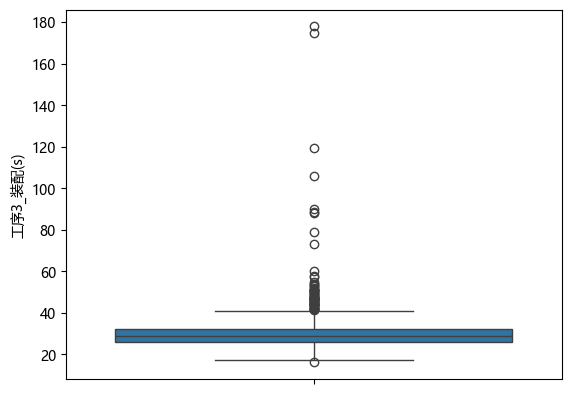

In [25]:
sns.boxplot(data=c_d,  y='工序3_装配(s)')
plt.show()

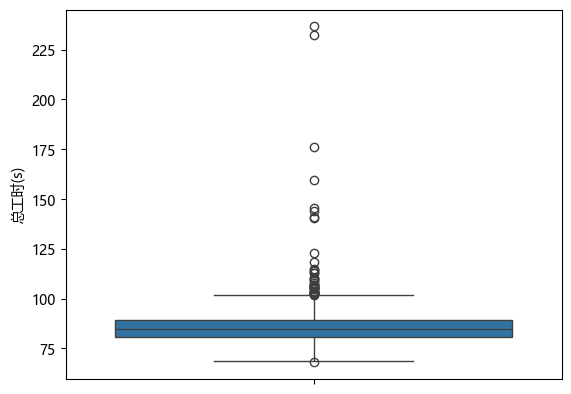

In [26]:
sns.boxplot(data=c_d,  y='总工时(s)')
plt.show()

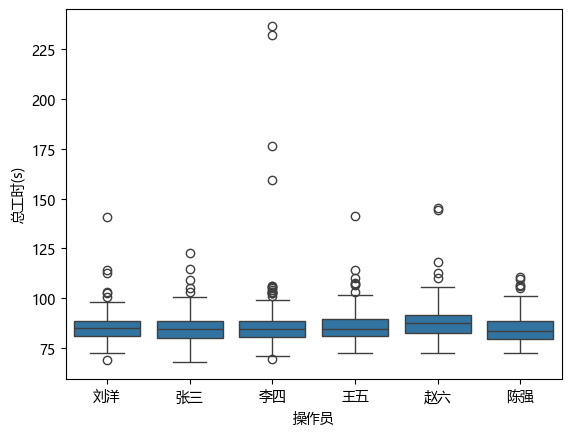

In [27]:
sns.boxplot(data=c_d, x='操作员', y='总工时(s)')
plt.savefig('不同操作员总工时对比', bbox_inches='tight')
plt.show()

可以发现工序3装配时长 出现了不少异常值、但总工时基本上也和装配时间相对应、可能是制造过程出现异常 因此暂时不需要删除 等后续继续判断是否保留  

其余数值初步判断没有问题

先筛选出来总工时很大的值、看是否装配时间和它在同一行

In [28]:
c_d[c_d["总工时(s)"] > 150]

,产品编号,日期,班次,操作员,工序1_下料(s),工序2_加工(s),工序3_装配(s),工序4_检测(s),工序5_包装(s),停机时间(s),总工时(s)
142,P00143,2026-01-08,白班,李四,14.13,17.33,119.190941,15.23,10.42,0.00,176.300941
272,P00273,2026-01-14,白班,李四,13.88,20.18,177.923372,15.58,9.15,24.95,236.713372
505,P00506,2026-01-26,白班,李四,12.86,17.50,174.521802,16.36,11.04,10.73,232.281802
699,P00700,2026-02-04,白班,李四,11.08,16.41,105.737230,15.87,10.26,0.00,159.357230


可以发现`总工时`很大的制造过程 都是在`装配过程`耗时长  

且操作员均为 `李四` 因此判断不是异常数据、无需进行删除

#### 判断数据是否合格

数据合格的意思是指、符合常理、比如在这套数据中、我们要判断总工时是否等于五个工序与停机时间之和

In [29]:
# 1. 计算五个工序与停机时间的和
sum_cols = ['工序1_下料(s)', '工序2_加工(s)', '工序3_装配(s)', '工序4_检测(s)', '工序5_包装(s)', '停机时间(s)']
c_d['计算总和'] = c_d[sum_cols].sum(axis=1)

# 2. 计算差值（总工时 - 计算总和）
c_d['差值'] = c_d['总工时(s)'] - c_d['计算总和']

# 3. 判断是否相等（考虑浮点精度，差值绝对值小于 1e-3 视为相等）
tolerance = 1e-3
c_d['是否相等'] = abs(c_d['差值']) < tolerance

# 4. 输出统计信息
print("总行数:", len(c_d))
print("不匹配的行数:", (~c_d['是否相等']).sum())
print("差值描述统计:")
print(c_d['差值'].describe())

# 5. 查看不匹配的行（如果有）
mismatched = c_d[~c_d['是否相等']]
if len(mismatched) > 0:
    print("\n不匹配的行（前5行）:")
    display(mismatched[['产品编号', '总工时(s)', '计算总和', '差值']].head())

总行数: 970
不匹配的行数: 86
差值描述统计:
count    9.700000e+02
mean    -1.349371e+00
std      4.653773e+00
min     -2.495000e+01
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.842171e-14
Name: 差值, dtype: float64

不匹配的行（前5行）:


,产品编号,总工时(s),计算总和,差值
3,P00004,96.58,104.90,-8.32
5,P00006,96.04,108.80,-12.76
20,P00021,91.29,102.31,-11.02
35,P00036,93.16,101.27,-8.11
43,P00044,101.59,117.35,-15.76


可以看到 还是有不少行的总工时与实际统计时间不匹配的  
接下来观察一下有差值的总体

In [30]:
c_d.loc[c_d['差值'] < -0.1, ['产品编号', '总工时(s)', '工序1_下料(s)', '工序2_加工(s)', 
                              '工序3_装配(s)', '工序4_检测(s)', '工序5_包装(s)', 
                              '停机时间(s)', '计算总和', '差值']].head(100)

,产品编号,总工时(s),工序1_下料(s),工序2_加工(s),工序3_装配(s),工序4_检测(s),工序5_包装(s),停机时间(s),计算总和,差值
3,P00004,96.58,11.07,18.10,39.31,16.26,11.84,8.32,104.90,-8.32
5,P00006,96.04,12.66,19.15,39.31,16.49,8.43,12.76,108.80,-12.76
20,P00021,91.29,10.59,19.90,37.66,15.69,7.45,11.02,102.31,-11.02
35,P00036,93.16,13.74,17.27,38.56,13.84,9.75,8.11,101.27,-8.11
43,P00044,101.59,12.01,17.99,46.04,14.98,10.57,15.76,117.35,-15.76
...,...,...,...,...,...,...,...,...,...,...
956,P00957,83.86,12.19,17.93,29.29,16.25,8.20,5.90,89.76,-5.90
971,P00972,96.15,14.13,17.48,41.71,15.10,7.73,12.79,108.94,-12.79
976,P00977,106.25,12.55,17.29,50.59,17.55,8.27,19.43,125.68,-19.43
983,P00984,93.30,11.86,17.40,36.79,18.59,8.66,6.66,99.96,-6.66


In [31]:
c_d.loc[c_d['差值'] > 0.1, ['产品编号', '总工时(s)', '工序1_下料(s)', '工序2_加工(s)', 
                              '工序3_装配(s)', '工序4_检测(s)', '工序5_包装(s)', 
                              '停机时间(s)', '计算总和', '差值']].head()

,产品编号,总工时(s),工序1_下料(s),工序2_加工(s),工序3_装配(s),工序4_检测(s),工序5_包装(s),停机时间(s),计算总和,差值


所得的这86行都是计算出的总时间与总工时相比有差值的、不符合常理、因数据量很大、直接删除就好

In [32]:
keep_mask = abs(c_d['差值']) <= 1e-3

# 删除不匹配的行
c_d = c_d[keep_mask].reset_index(drop=True)

# 确认无删除后的不匹配行
print(f"剩余行数: {len(c_d)}")
print(f"不匹配行数: {abs(c_d['差值'] > 1e-3).sum()}")   # 应为0

剩余行数: 884
不匹配行数: 0


再重新看一下之前所求的总工时很大行

In [33]:
c_d[c_d["总工时(s)"] > 150]

,产品编号,日期,班次,操作员,工序1_下料(s),工序2_加工(s),工序3_装配(s),工序4_检测(s),工序5_包装(s),停机时间(s),总工时(s),计算总和,差值,是否相等
128,P00143,2026-01-08,白班,李四,14.13,17.33,119.190941,15.23,10.42,0.0,176.300941,176.300941,2.842171e-14,True
609,P00700,2026-02-04,白班,李四,11.08,16.41,105.737230,15.87,10.26,0.0,159.357230,159.357230,0.000000e+00,True


发现少了两行、之前有两行异常数据在其中

由于产品编号不是传统意义上的产品编号、可认为生产的是同一产品、计算总和、产值与是否相等列已经没有用了  
这里删去

In [34]:
c_d = c_d.drop(columns=['计算总和', '差值', '是否相等','产品编号'])

In [35]:
c_d

,日期,班次,操作员,工序1_下料(s),工序2_加工(s),工序3_装配(s),工序4_检测(s),工序5_包装(s),停机时间(s),总工时(s)
0,2026-01-01,白班,王五,13.87,19.04,25.40,14.61,10.79,0.0,83.71
1,2026-01-01,白班,李四,13.96,18.80,28.67,13.86,8.84,0.0,84.13
2,2026-01-01,白班,李四,11.53,17.11,21.98,16.36,9.95,0.0,76.93
3,2026-01-01,白班,刘洋,10.83,16.64,30.57,12.87,10.77,0.0,81.68
4,2026-01-01,白班,刘洋,10.71,18.37,29.81,14.68,9.43,0.0,83.00
...,...,...,...,...,...,...,...,...,...,...
879,2026-02-19,白班,刘洋,9.63,13.30,29.08,9.71,11.47,0.0,73.19
880,2026-02-19,夜班,刘洋,11.58,15.75,31.71,13.11,9.54,0.0,81.69
881,2026-02-19,白班,刘洋,9.90,14.41,31.76,13.88,9.17,0.0,79.12
882,2026-02-19,白班,陈强,11.00,20.37,28.10,14.76,10.44,0.0,84.67


至此、数据清理过程结束

## 保存清理后的数据

完成数据清理后，把干净整齐的数据保存到新的文件里，文件名为`cleaned_IE_Bottleneck_Study`。

In [36]:
c_d.to_csv("cleaned_IE_Bottleneck_Study", index=False)

In [37]:
pd.read_csv("cleaned_IE_Bottleneck_Study").head()

,日期,班次,操作员,工序1_下料(s),工序2_加工(s),工序3_装配(s),工序4_检测(s),工序5_包装(s),停机时间(s),总工时(s)
0,2026-01-01,白班,王五,13.87,19.04,25.40,14.61,10.79,0.0,83.71
1,2026-01-01,白班,李四,13.96,18.80,28.67,13.86,8.84,0.0,84.13
2,2026-01-01,白班,李四,11.53,17.11,21.98,16.36,9.95,0.0,76.93
3,2026-01-01,白班,刘洋,10.83,16.64,30.57,12.87,10.77,0.0,81.68
4,2026-01-01,白班,刘洋,10.71,18.37,29.81,14.68,9.43,0.0,83.00


可以看到、清理后的数据已成功导出

## 整理与探索数据

接下来 开始进行整理与探索数据环节

对数据的整理，与分析方向紧密相关。此次数据分析目标是  
基于制造过程中收集到的数据，分析哪个工序是瓶颈、哪些因素影响生产效率、是否存在班次差异、是否存在操作员差异、如何改善  
让我们可以对生产过程有个更清晰的认识和更明确的改善思路。  

接下来按照 **5M1E** 分析制造过程 但受数据的局限、可能无法分析所有方面

### 按**环**分类

我们有理由相信、班次会对制造过程有影响、因此、我们可以对数据基于`班次`列，先把各个生产产品以班次为分类、将样本数据筛选出来。

#### 整理数据

In [38]:
work_moning = c_d.query('班次 == "白班"')
work_night = c_d.query('班次 == "夜班"')

In [39]:
print(len(work_moning))
print(len(work_night))

543
341


可以看到白班约占60%、夜班占40%

#### 探索数据

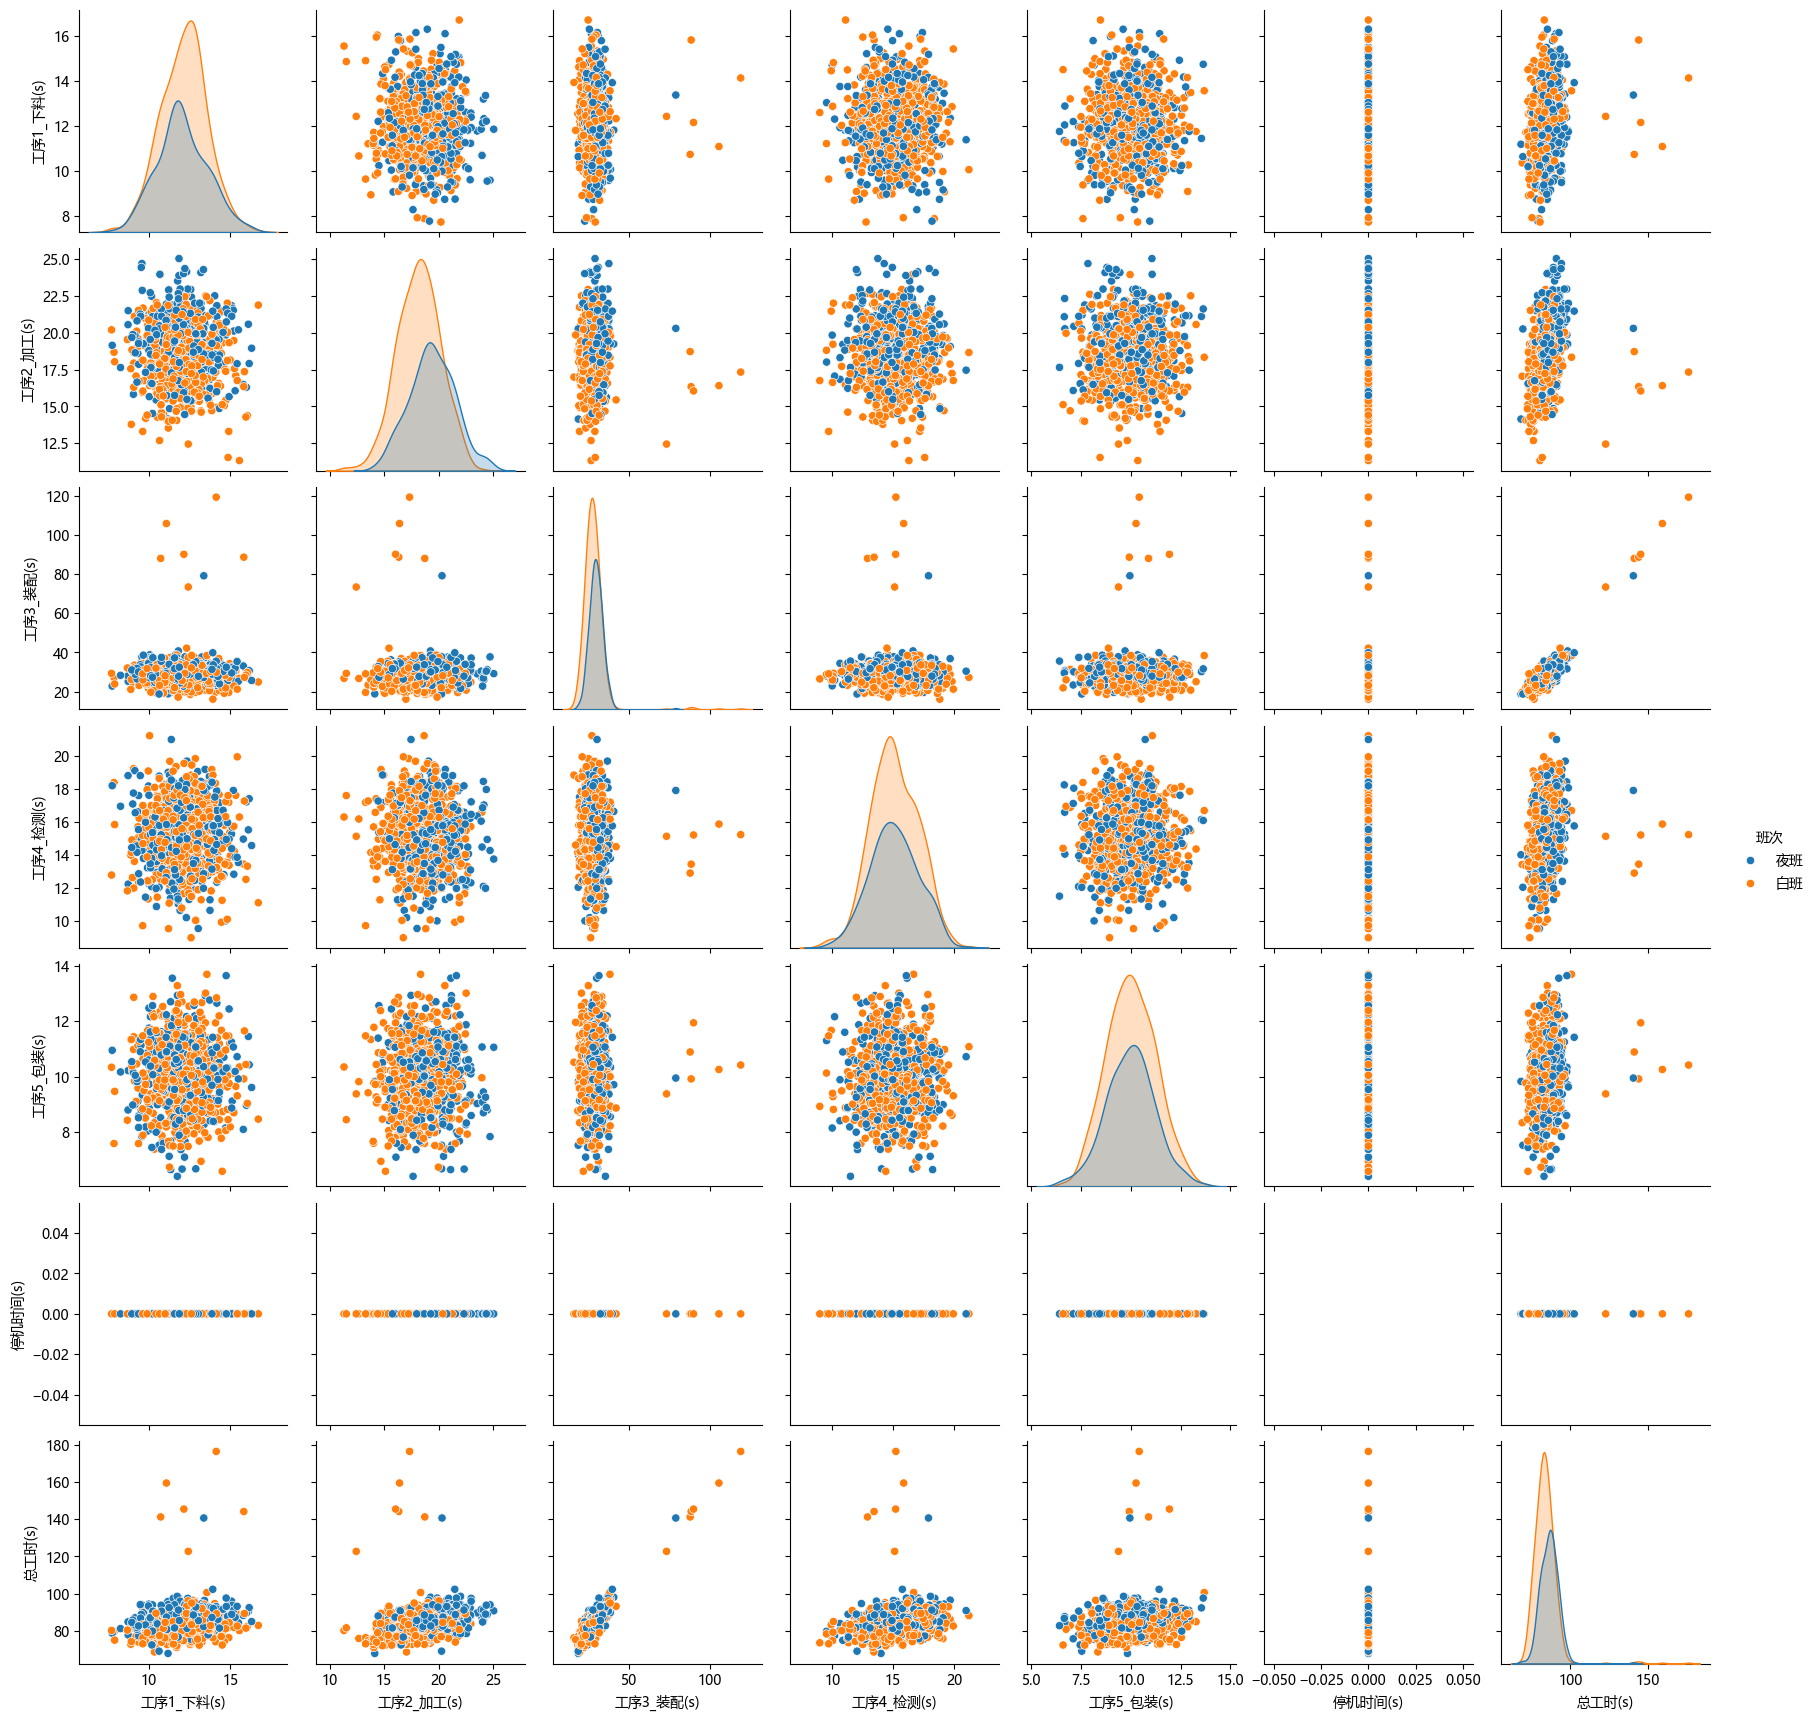

In [40]:
sns.pairplot(c_d, hue="班次")
plt.show()

可以看到白班的工作时长整体都要比夜班的高  
接下来运用假设检验分析是否存在统计显著性差异。

#### 分析数据

由于我们只有样本数据，不知道总体的标准差，加上两组样本数各为543和341，样本数量大，因此进行z检验，而不是t检验。假设此数据集样本符合z检验的两个前提：样本为随机抽样，总体呈正态分布。

首先导入z检验函数

In [41]:
from statsmodels.stats.weightstats import ztest

In [42]:
work_moring_tt = work_moning['总工时(s)']

In [43]:
work_night_tt= work_night['总工时(s)']

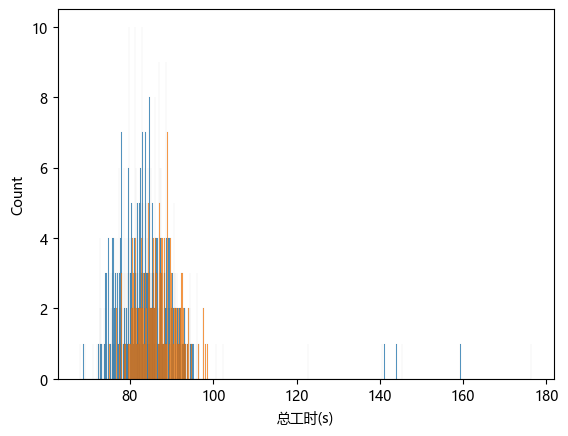

In [44]:
sns.histplot(work_moring_tt, binwidth=0.1)
sns.histplot(work_night_tt, binwidth=0.1)
plt.show()

##### 建立假设

$H_0$：班次和总工时之间不存在显著区别。

$H_1$：班次和总工时之间存在显著区别。

##### 确定显著水平

我们将0.05作为显著水平

##### 计算z值和p值

In [45]:
# 计算z值和p值（双尾）
z_stat, p_value = ztest(work_moring_tt, work_night_tt, 
                        alternative='two-sided')
print(z_stat, p_value)

# 显著水平为0.05
alpha = 0.05

# 比较计算出的p值和显著水平
if p_value < alpha:
    print('两组数据有显著差异')
else:
    print('两组数据无显著差异')

-4.73641356974254 2.1753344982350277e-06
两组数据有显著差异


##### 结论

由于p值小于显著水平0.05，我们因此拒绝原假设，说明班次和总工时之间存在显著影响。

### 按**人**分类

#### 整理数据

在评估与清洗数据环节、我们看到操作员对数据好像是有明显区别、那么我们可以对数据基于 `操作员` 列，先把各个生产产品以操作员为分类、将样本数据筛选出来。

In [46]:
operator_liu = c_d.query('操作员 == "刘洋"')
operator_zhang = c_d.query('操作员 == "张三"')
operator_li = c_d.query('操作员 == "李四"')
operator_wang = c_d.query('操作员 == "王五"')
operator_zhao = c_d.query('操作员 == "赵六"')
operator_chen = c_d.query('操作员 == "陈强"')

In [47]:
print(len(operator_liu))
print(len(operator_zhang))
print(len(operator_li))
print(len(operator_wang))
print(len(operator_zhao))
print(len(operator_chen))

156
130
158
131
153
156


可以看到统计数据都有足够的样本量

#### 探索数据

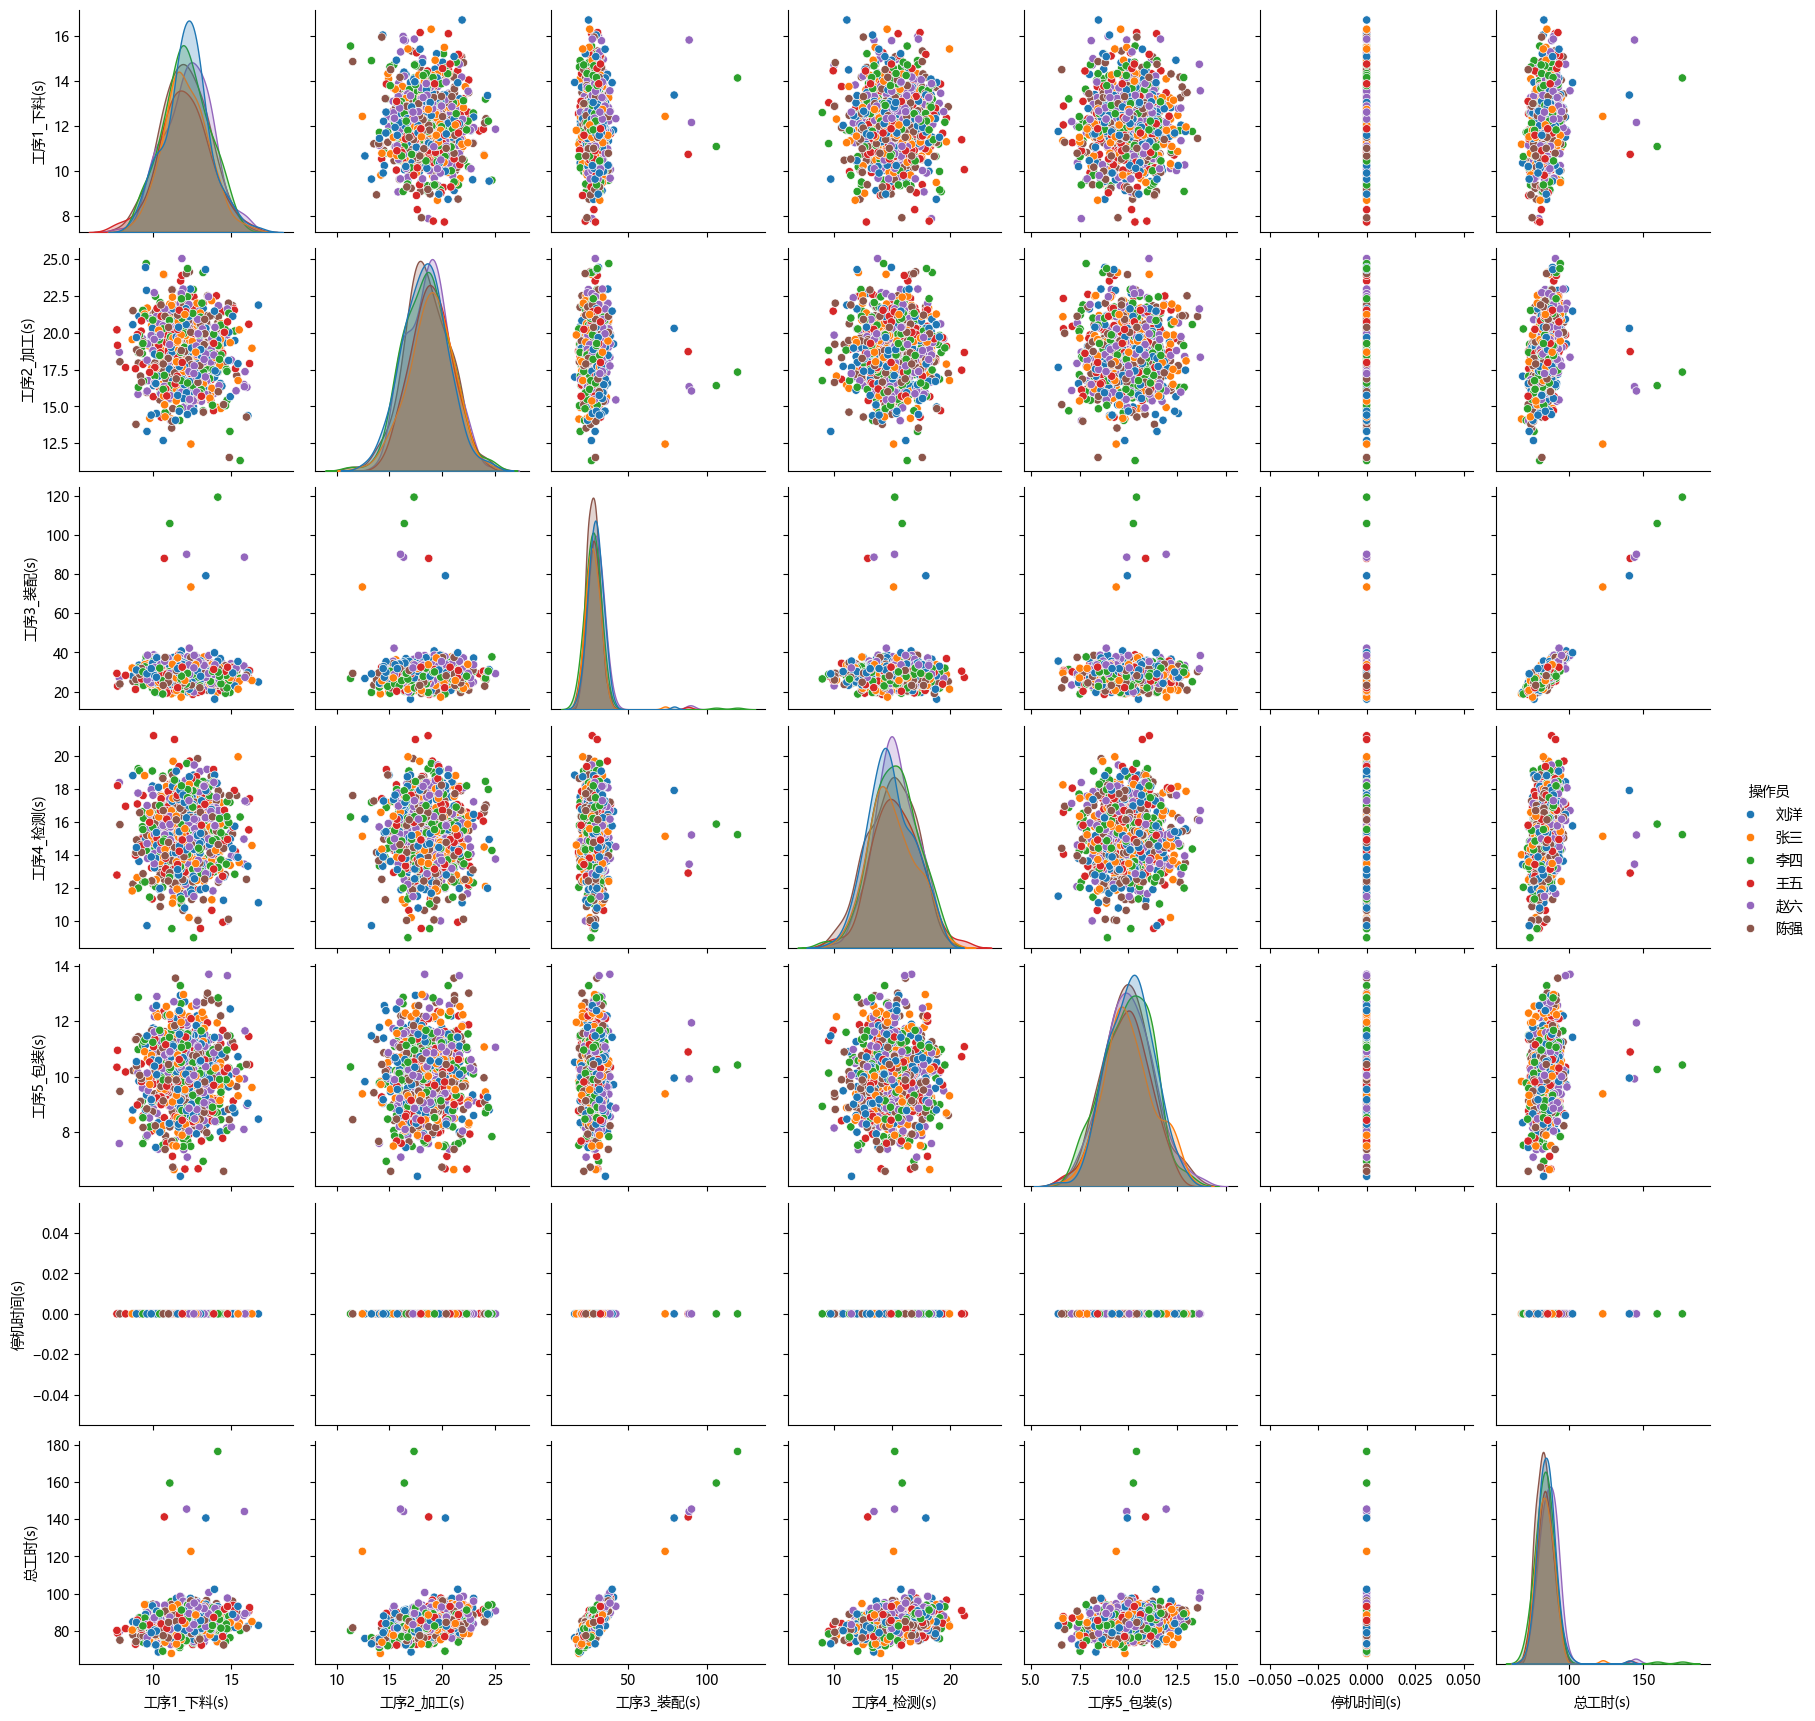

In [48]:
sns.pairplot(c_d, hue="操作员")
plt.show()

数据过于复杂、不适合从整体判断

### 关于其他方面

由于数据中没有给出机、料、法的信息 暂时只能认为这些条件都一样 无法进行分析

### 分析瓶颈工序

这个单元、旨在分析加工过程中哪个工序所占时间最长、成为瓶颈工序  
以便后续改善

首先、从数据层面分析一下各工序的耗时

#### 数据分析

In [49]:
# 选择工序耗时列
process_cols = ['工序1_下料(s)', '工序2_加工(s)', '工序3_装配(s)', 
                 '工序4_检测(s)', '工序5_包装(s)']

# 1. 描述性统计
print("=== 各工序耗时描述性统计 ===")
desc = c_d[process_cols].describe()
print(desc)

# 2. 各工序总耗时占比（总工时 = 各工序耗时 + 停机时间，但此处单独看工序）
process_sum = c_d[process_cols].sum()
process_total = process_sum.sum()
print("\n=== 各工序耗时占所有工序总耗时比例 ===")
for col in process_cols:
    ratio = process_sum[col] / process_total * 100
    print(f"{col:15s} : {ratio:.2f}%")


=== 各工序耗时描述性统计 ===
        工序1_下料(s)   工序2_加工(s)   工序3_装配(s)  工序4_检测(s)   工序5_包装(s)
count  884.000000  884.000000  884.000000  884.00000  884.000000
mean    12.100498   18.634299   28.859786   15.10164    9.996799
std      1.468352    2.103463    7.125153    1.95936    1.228394
min      7.720000   11.320000   16.160000    8.98000    6.410000
25%     11.167500   17.190000   25.527500   13.71750    9.130000
50%     12.080000   18.640000   28.345000   14.97500    9.990000
75%     13.042500   20.000000   31.210000   16.53000   10.830000
max     16.710000   25.040000  119.190941   21.23000   13.690000

=== 各工序耗时占所有工序总耗时比例 ===
工序1_下料(s)       : 14.29%
工序2_加工(s)       : 22.00%
工序3_装配(s)       : 34.08%
工序4_检测(s)       : 17.83%
工序5_包装(s)       : 11.80%


可以看到、单是装配环节就占总时间三分之一的时间、还不包括停机时间  

接下来以图示的形式观察数据

#### 图示观察

In [50]:
# 工序列名
process_cols = ['工序1_下料(s)', '工序2_加工(s)', '工序3_装配(s)', '工序4_检测(s)', '工序5_包装(s)']

# 确保数值类型
for col in process_cols:
    c_d[col] = pd.to_numeric(c_d[col], errors='coerce')


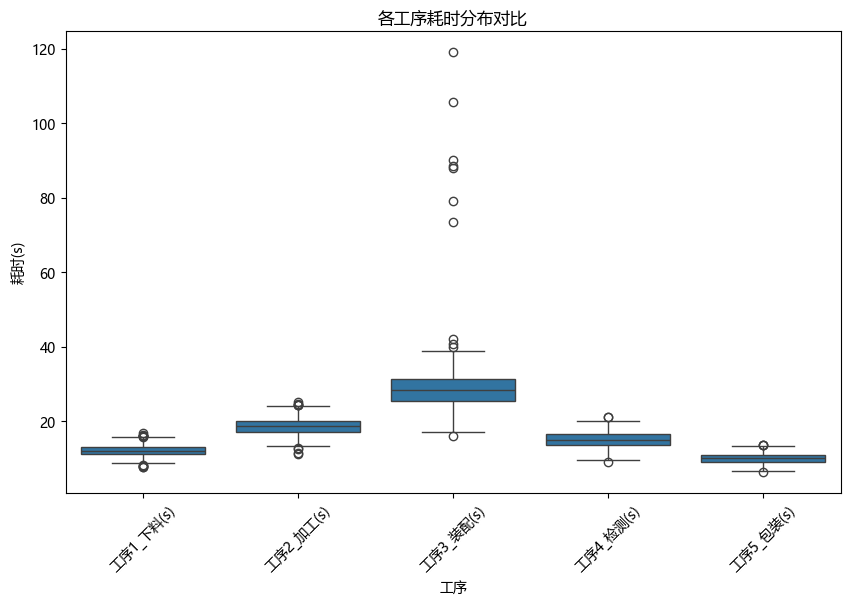

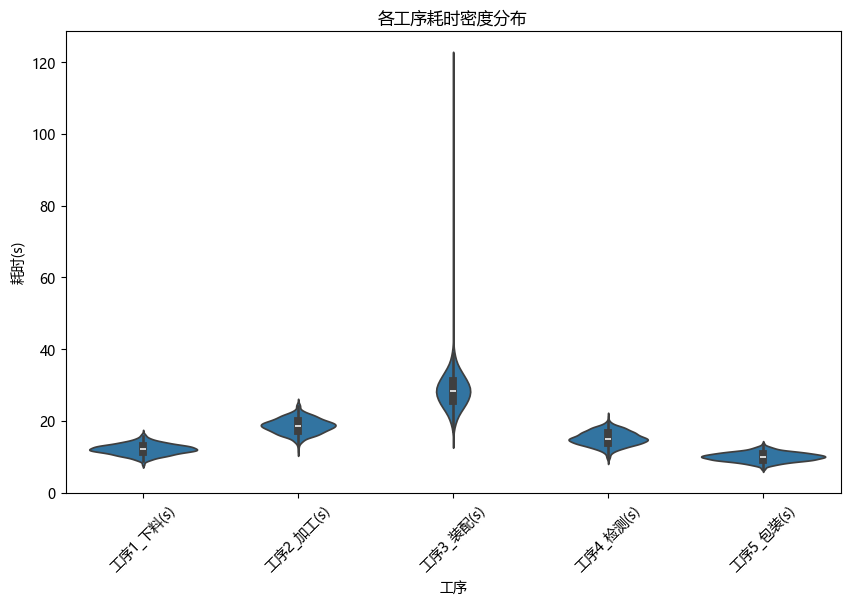

In [51]:
# 将数据转换为长格式
df_melt = c_d.melt(id_vars=['日期', '班次', '操作员'], 
                  value_vars=process_cols,
                  var_name='工序', value_name='耗时(s)')

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_melt, x='工序', y='耗时(s)')
plt.title('各工序耗时分布对比')
plt.xticks(rotation=45)
plt.savefig('各工序耗时分布对比', bbox_inches='tight')
plt.show()

# 小提琴图（展示密度分布）
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_melt, x='工序', y='耗时(s)')
plt.title('各工序耗时密度分布')
plt.xticks(rotation=45)
plt.savefig('各工序耗时密度分布', bbox_inches='tight')
plt.show()

发现工序3 装配步骤耗时明显长与其他四项工序、且时`不合理`的长耗时  

再利用饼图来观察一下各工序占总工时的比例

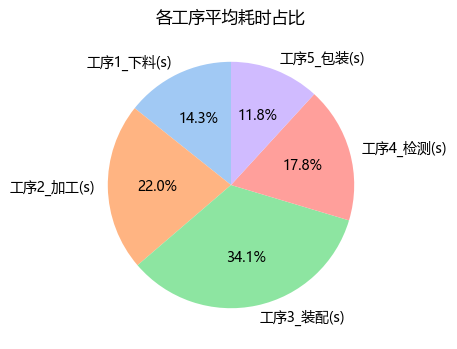

In [52]:
mean_time = c_d[process_cols].mean()
plt.figure(figsize=(4,4))
plt.pie(mean_time, labels=mean_time.index, autopct='%1.1f%%', startangle=90, 
        colors=sns.color_palette('pastel'))
plt.title('各工序平均耗时占比')
plt.savefig('各工序耗时占比', bbox_inches='tight')
plt.show()

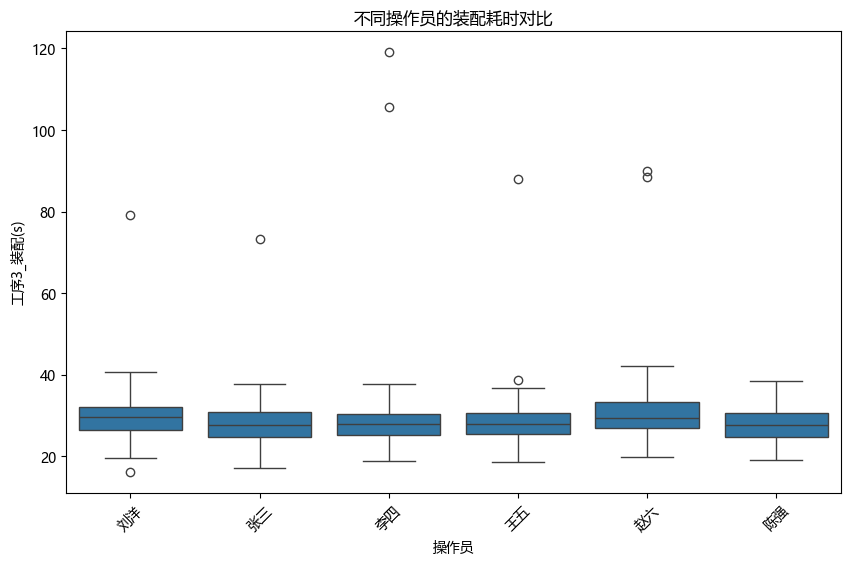

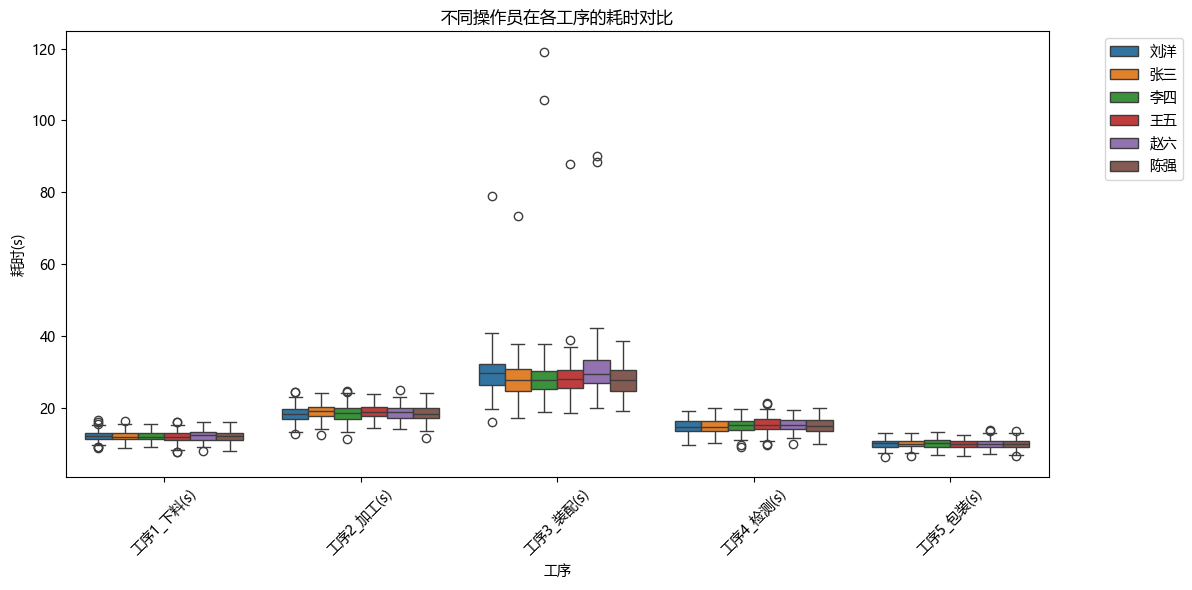

In [53]:
# 以操作员分组，查看工序3_装配(s)耗时差异
plt.figure(figsize=(10, 6))
sns.boxplot(data=c_d, x='操作员', y='工序3_装配(s)')
plt.title('不同操作员的装配耗时对比')
plt.xticks(rotation=45)
plt.savefig('不同操作员的装配耗时对比', bbox_inches='tight')
plt.show()

# 多工序对比（使用长格式 + hue）
df_melt_op = c_d.melt(id_vars=['操作员'], value_vars=process_cols, 
                     var_name='工序', value_name='耗时(s)')
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melt_op, x='工序', y='耗时(s)', hue='操作员')
plt.title('不同操作员在各工序的耗时对比')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('不同操作员在各工序的耗时对比', bbox_inches='tight')
plt.show()

可以看到：大部分操作员的正常装配耗时非常接近且稳定，但所有操作员都存在极端的“耗时过长”异常情况，其中`李四`的异常值极为突出。  
整条产线（工序1-5）中，只有`工序3_装配`是绝对的瓶颈，其他所有工序的执行时间都非常稳定且耗时极短。

既然所有人的常规时间都差不多，解决产线瓶颈的关键不在于提升所有人的“手速”，而在于消除那些“异常耗时”。

建议对**李四**的个案分析 ：
立即找到李四耗时 100秒以上 的那几次装配记录。查看当时的物料、设备状态、操作流程。很有可能这是“物料异常卡顿”或“某种反复纠正动作”导致的。  
因为其他人或多或少也有超出正常值的数据、所以说因操作员自身不合格导致过程异常的可能性不大

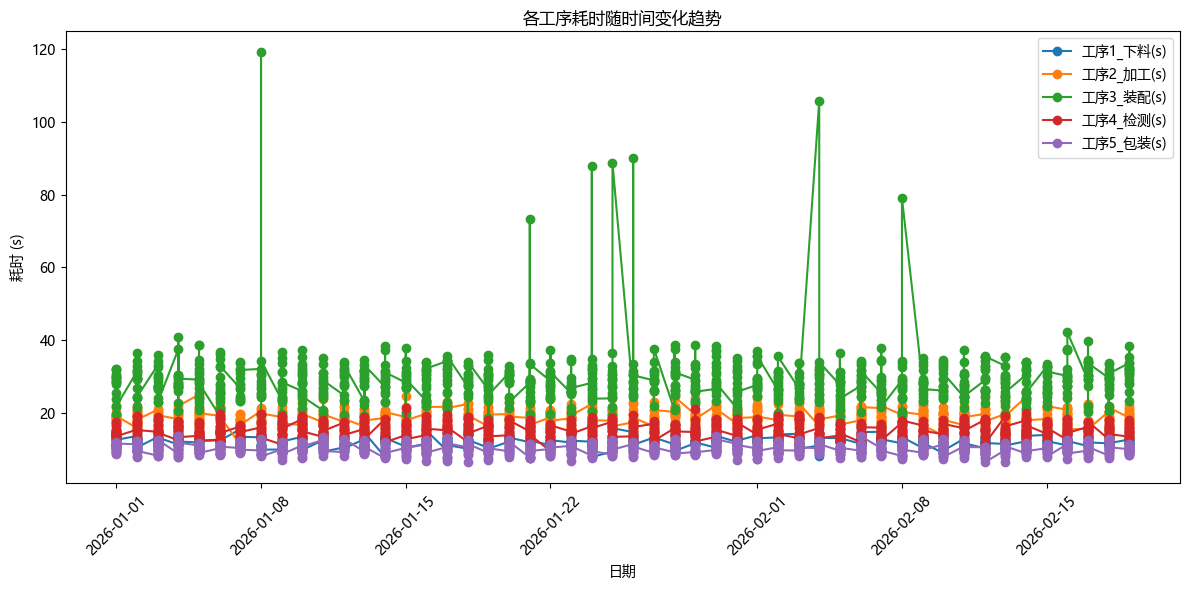

In [54]:
# 假设日期列已解析为 datetime
c_d['日期'] = pd.to_datetime(c_d['日期'])
c_d_sorted = c_d.sort_values('日期')

plt.figure(figsize=(12, 6))
for col in process_cols:
    plt.plot(c_d_sorted['日期'], c_d_sorted[col], marker='o', label=col)
plt.xlabel('日期')
plt.ylabel('耗时 (s)')
plt.title('各工序耗时随时间变化趋势')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

可以看到工序随时间的变化没有明显趋势、时间应该不是显著影响总工时的关键因素

## 结论

通过数据分析、图示观察等方法，我们发现  
班次对于总工时有着显著影响  
工序3 装配阶段属于整个操作流程的瓶颈工序、后续应对工序3进行分析与简化、使生产节拍平衡  

后续应收集具体数据 判别并改善影响生产的关键因素